# Classifier-Gradient-Guided Evaluation Analysis
**Experiment:** `classifier_gradient_guidance` (varying guidance_scale, no autoregressive action, 20k steps)

In [1]:
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tabulate import tabulate

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 120,
})

# ── Data loading ──

BASE_DIR = (
    "/global/scratch/users/yajatyadav/research/multitask_reinforcement_learning/polaris"
    "/runs/classifier_guided_jobs"
)

EXPERIMENT_PATTERN = "classifier_gradient_guidance__*__logsigmoid_noannealT_20kstep_noautoregaction_*"


def load_all_results(base_dir: str = BASE_DIR) -> pd.DataFrame:
    """Walk all guidance_scale experiment directories and return a DataFrame with columns:
    guidance_scale, task, episode, episode_length, success, progress
    """
    rows = []
    for exp_dir in sorted(glob.glob(os.path.join(base_dir, EXPERIMENT_PATTERN))):
        # Extract guidance_scale from directory name
        dirname = os.path.basename(exp_dir)
        match = re.search(r'classifier_gradient_guidance__([\d.]+)__', dirname)
        if not match:
            continue
        guidance_scale = float(match.group(1))

        results_dir = os.path.join(exp_dir, "job_results")
        for csv_path in glob.glob(os.path.join(results_dir, "job_*", "N*", "*", "eval_results.csv")):
            parts = Path(csv_path).parts
            task_folder = parts[-2]
            # Extract task name (strip trailing date stamp)
            idx = task_folder.rfind("_202")
            task_name = task_folder[:idx] if idx != -1 else task_folder
            idx2 = task_name.rfind("_202")
            if idx2 != -1:
                task_name = task_name[:idx2]

            df = pd.read_csv(csv_path)
            df["guidance_scale"] = guidance_scale
            df["task"] = task_name
            rows.append(df)
    return pd.concat(rows, ignore_index=True)


def compute_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Group by (guidance_scale, task) and compute mean/sem for success and progress."""
    def _agg(g):
        n_rollouts = len(g)
        return pd.Series({
            "n_rollouts": n_rollouts,
            "success_mean": g["success"].mean(),
            "success_sem": g["success"].std(ddof=1) / np.sqrt(n_rollouts) if n_rollouts > 1 else 0,
            "progress_mean": g["progress"].mean(),
            "progress_sem": g["progress"].std(ddof=1) / np.sqrt(n_rollouts) if n_rollouts > 1 else 0,
        })
    return df.groupby(["guidance_scale", "task"]).apply(_agg).reset_index()


def compute_avg_stats(stats: pd.DataFrame) -> pd.DataFrame:
    """Average over tasks for each guidance_scale (propagate uncertainty)."""
    def _agg(g):
        n_tasks = len(g)
        return pd.Series({
            "n_rollouts_total": int(g["n_rollouts"].sum()),
            "success_mean": g["success_mean"].mean(),
            "success_sem": np.sqrt((g["success_sem"] ** 2).sum()) / n_tasks,
            "progress_mean": g["progress_mean"].mean(),
            "progress_sem": np.sqrt((g["progress_sem"] ** 2).sum()) / n_tasks,
        })
    return stats.groupby("guidance_scale").apply(_agg).reset_index()


# ── Plotting ──

def plot_guidance_curve(stats_df: pd.DataFrame, title: str = "Classifier Gradient Guidance"):
    """Line plot with x=guidance_scale, two lines (success, progress) with shaded error bars."""
    fig, ax = plt.subplots(figsize=(6, 4))
    xs = stats_df["guidance_scale"].values

    for metric, color, label in [
        ("success", "tab:blue", "Success Rate"),
        ("progress", "tab:orange", "Progress"),
    ]:
        mean = stats_df[f"{metric}_mean"].values
        sem = stats_df[f"{metric}_sem"].values
        ax.plot(xs, mean, "o-", color=color, label=label)
        ax.fill_between(xs, mean - sem, mean + sem, alpha=0.2, color=color)

    ax.set_xlabel("Guidance Scale")
    ax.set_ylabel("Value")
    ax.set_title(title)
    ax.set_xscale("symlog", linthresh=0.05)
    ax.set_xticks(xs)
    ax.set_xticklabels([str(x) for x in xs])
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    fig.tight_layout()
    return fig


def print_results_table(stats: pd.DataFrame):
    """Pretty-print the per-task, per-guidance_scale results table."""
    stats_sorted = stats.sort_values(["task", "guidance_scale"])
    table_rows = []
    for _, r in stats_sorted.iterrows():
        table_rows.append([
            r["task"], r["guidance_scale"], int(r["n_rollouts"]),
            f'{r["success_mean"]:.3f} ± {r["success_sem"]:.3f}',
            f'{r["progress_mean"]:.3f} ± {r["progress_sem"]:.3f}',
        ])
    print(tabulate(
        table_rows,
        headers=["Task", "Guidance Scale", "Rollouts", "Success (mean±sem)", "Progress (mean±sem)"],
        tablefmt="github",
    ))

## Load data & print results table

In [2]:
df = load_all_results()
stats = compute_stats(df)
print_results_table(stats)

| Task                    |   Guidance Scale |   Rollouts | Success (mean±sem)   | Progress (mean±sem)   |
|-------------------------|------------------|------------|----------------------|-----------------------|
| DROID-BlockStackKitchen |              0   |         50 | 0.000 ± 0.000        | 0.349 ± 0.025         |
| DROID-BlockStackKitchen |              0.1 |         50 | 0.000 ± 0.000        | 0.326 ± 0.021         |
| DROID-BlockStackKitchen |              0.3 |         50 | 0.000 ± 0.000        | 0.311 ± 0.023         |
| DROID-BlockStackKitchen |              1   |         50 | 0.000 ± 0.000        | 0.326 ± 0.027         |
| DROID-BlockStackKitchen |              3   |         50 | 0.000 ± 0.000        | 0.343 ± 0.020         |
| DROID-BlockStackKitchen |             10   |         50 | 0.000 ± 0.000        | 0.329 ± 0.024         |
| DROID-FoodBussing       |              0   |         50 | 0.000 ± 0.000        | 0.343 ± 0.024         |
| DROID-FoodBussing       |          

## Averaged over all tasks

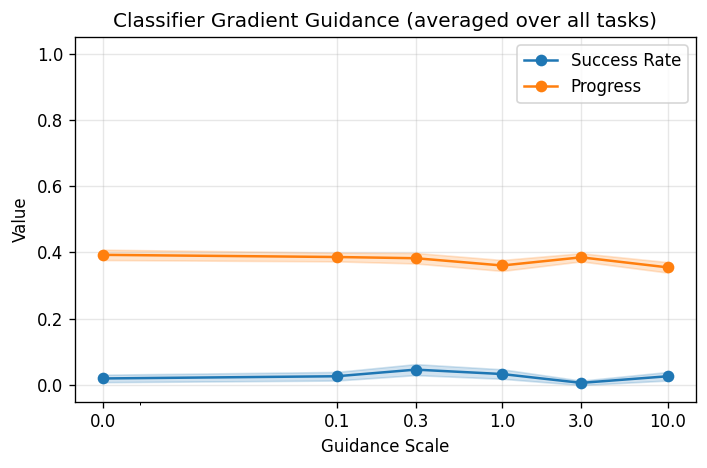

In [3]:
avg_stats = compute_avg_stats(stats)
plot_guidance_curve(avg_stats, title="Classifier Gradient Guidance (averaged over all tasks)")
plt.show()

## Per-task plots

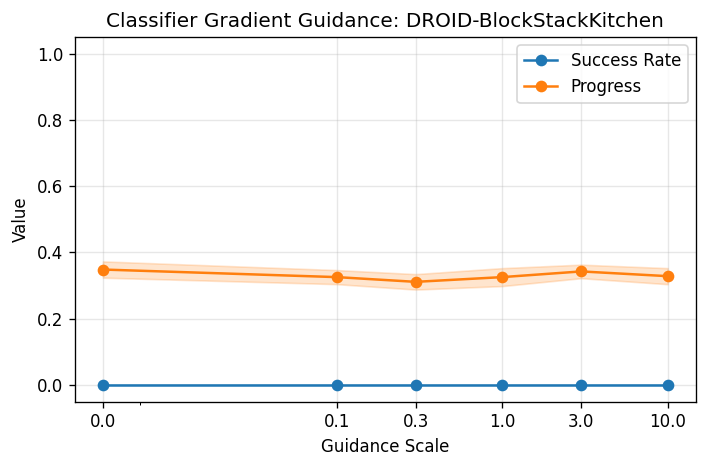

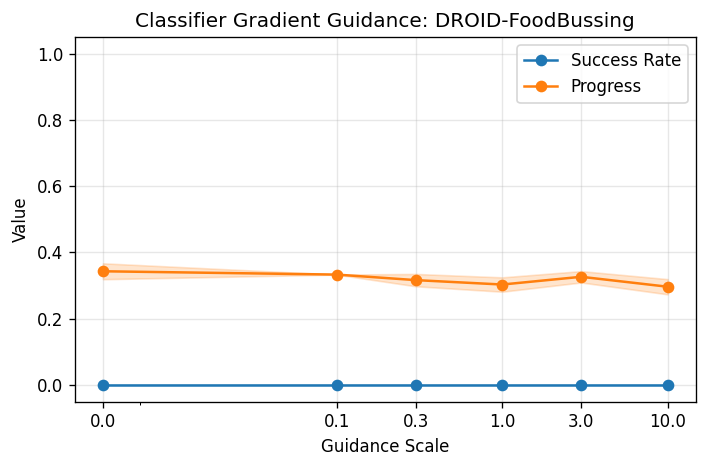

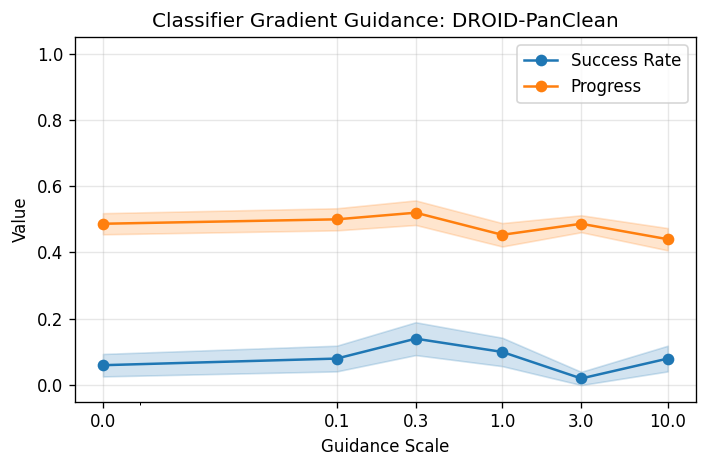

In [4]:
for task in sorted(stats["task"].unique()):
    task_stats = stats[stats["task"] == task].sort_values("guidance_scale")
    plot_guidance_curve(task_stats, title=f"Classifier Gradient Guidance: {task}")
    plt.show()